<a href="https://colab.research.google.com/github/pavan-1309/3-tier-web-application/blob/main/mlproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Context**

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data Scientist at AllLife Bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

# **Objective**

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and to identify which segment of customers to target more.

# **Data Dictionary**

- ID: Customer ID
- Age: Customer’s age in completed years
- Experience: # years of professional experience
- Income: Annual income of the customer (in thousand dollars)
- ZIP Code: Home Address ZIP code.
- Family: The family size of the customer
- CCAvg: Average spending on credit cards per month (in thousand dollars)
- Education: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
- Mortgage: Value of house mortgage if any. (in thousand dollars)
- Personal_Loan: Did this customer accept the personal loan offered in the last campaign?
- Securities_Account: Does the customer have a securities account with the bank?
- CD_Account: Does the customer have a certificate of deposit (CD) account with the bank?
- Online: Do customers use Internet banking facilities?
- CreditCard: Does the customer use a credit card issued by any other Bank (excluding All Life Bank)?

In [62]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split data
from sklearn.model_selection import train_test_split

# to build decision tree
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# to evaluate model performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# to suppress warnings
import warnings
warnings.filterwarnings('ignore')

# for reproducibility
import random
random.seed(42)
np.random.seed(42)

# **Loading the data**

In [63]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
# loading data into a pandas dataframe
#data = pd.read_csv("Loan_Modelling.csv")
data = pd.read_csv("/content/drive/MyDrive/CSV_Files/Loan_Modelling.csv")

# **Data Overview**

## **Checking the first 5 rows**

In [65]:
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## **Checking the shape of the data**

In [66]:
data.shape

(5000, 14)

In [67]:
data.shape

(5000, 14)

- The dataset contains **5000 Rows** and **14 Columns**.

## **Checking the attribute types**

In [68]:
# checking the attributes types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


- There are **14 numerical variables** in the dataset, including **1 float variable** and **13 integer variables**.

## **Checking the statistical summary**

In [69]:
# checking the statistical summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


## **Checking for missing values**

In [70]:
# checking for missing values
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


- There are **no missing values** in any column of your dataset.

## **Checking for duplicate values**

In [71]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

- The dataset **does not contain** any **duplicate records**.

# **Exploratory Data Analysis**

## **Univariate Analysis**

### **Age**

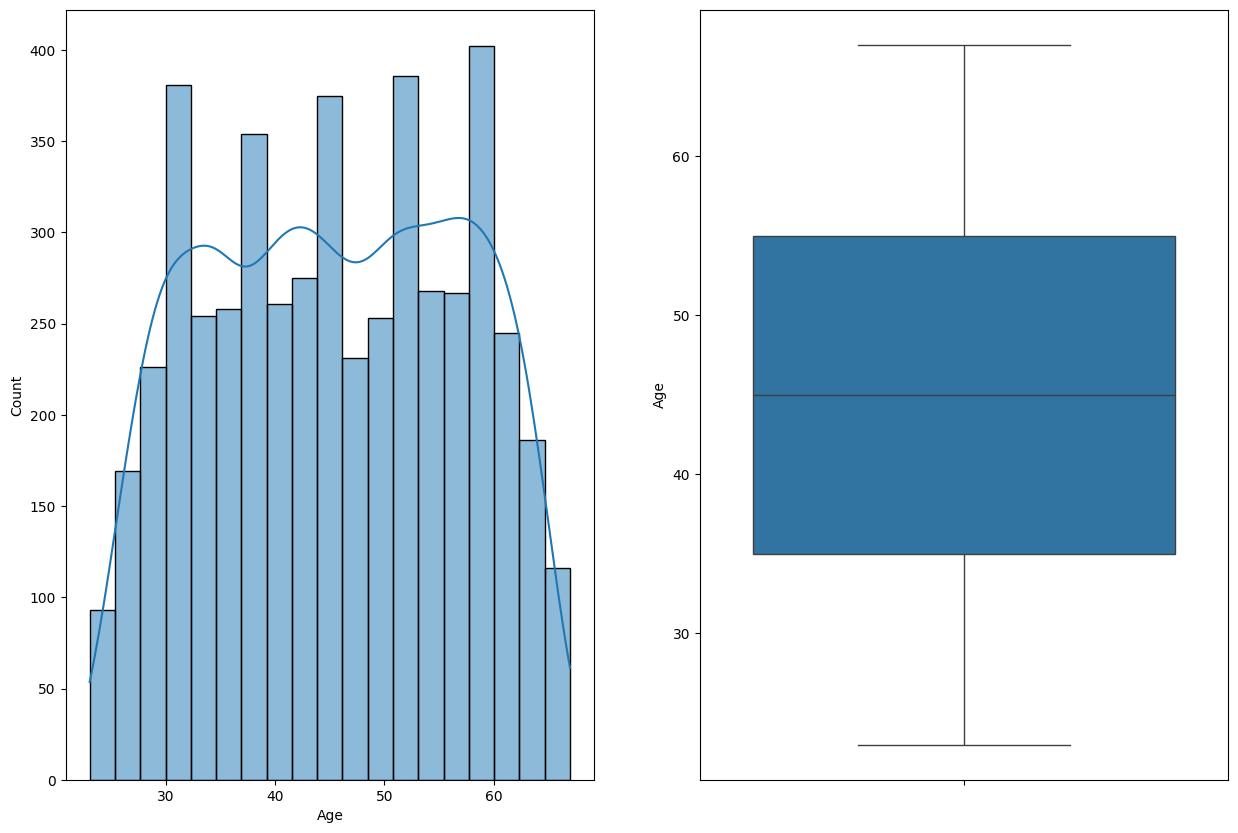

In [72]:
#histogram and Boxplot for age column
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
sns.histplot(data['Age'], kde=True)
plt.subplot(1,2,2)
sns.boxplot(data['Age'])
plt.show();

#### **Observation**

**Histogram Observation**
- The distribution is nearly uniform and symmetric, most customers fall between 30–60 years.
- A slight spike is visible around age 58–60.**bold text**

**Boxplot Observation**
- The box ranges from about 35 (Q1) to 55 (Q3), with the median around 45 right in the middle, which suggests the data is fairly balanced and not skewed.
- The whiskers stretch from roughly 23 to 67, and there are no outliers visible.- Overall, age looks like a clean variable with no issues that need fixing.

In [73]:
# calculate basic statistics (mean, median, minimum, and maximum) for Age
print('Mean:',data['Age'].mean())
print('Median:',data['Age'].median())
print('Min:',data['Age'].min())
print('Max:',data['Age'].max())

Mean: 45.3384
Median: 45.0
Min: 23
Max: 67


### Experience

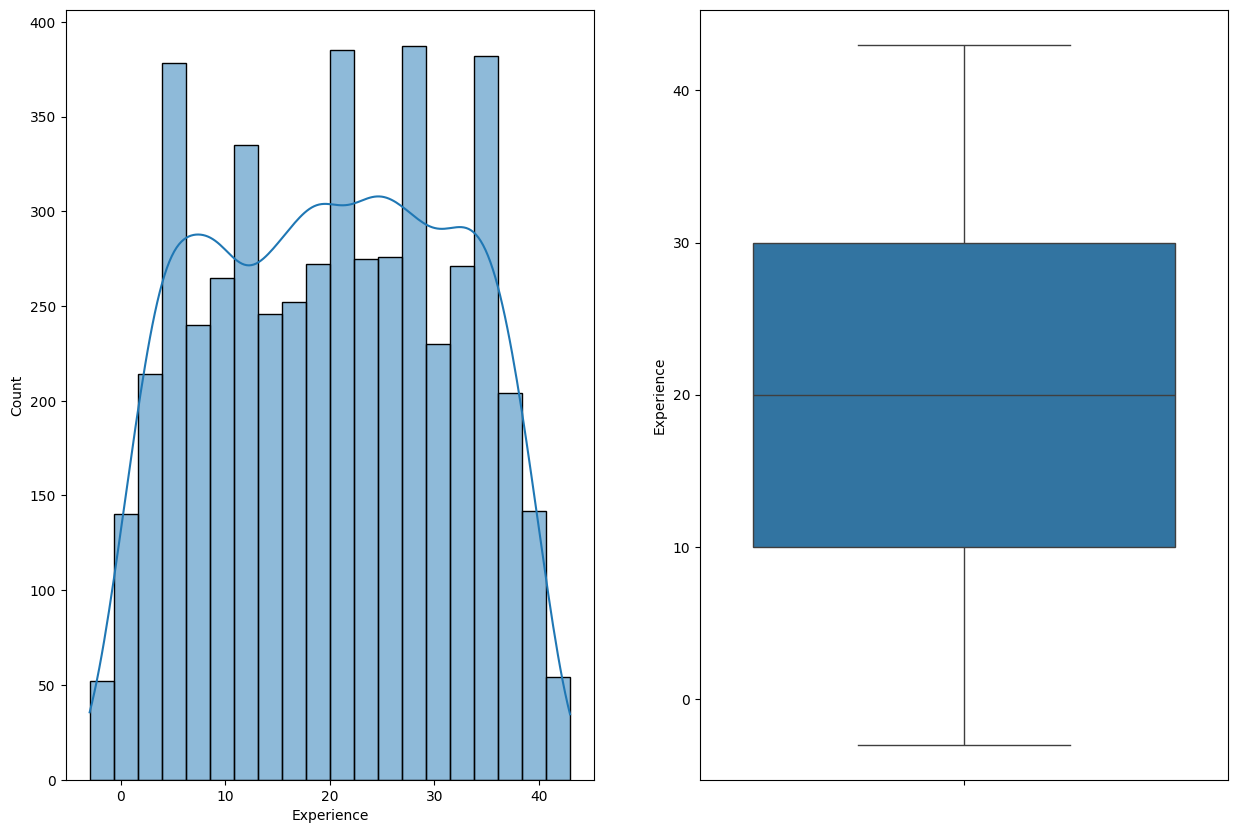

In [74]:
#Histogram and Boxplot for Experience Column
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
sns.histplot(data['Experience'], kde=True)
plt.subplot(1,2,2)
sns.boxplot(data['Experience'])
plt.show();

#### **Observation**

**Histogram Observation**
- The distribution appears fairly even and balanced, much like Age, with experience values spread from around 0 to 43 years.
- However, there are some negative values visible just below 0, confirming the incorrect entries we identified earlier. These should be handled before moving forward with modeling.

**Boxplot Observation**
- The box ranges from roughly 10 (Q1) to 30 (Q3), with the median around 20, showing a balanced and symmetric distribution, which matches what we saw in the histogram.
- However, the lower whisker extends below 0, clearly indicating the presence of negative experience values. These need to be corrected before proceeding with modeling.

In [75]:
#calculate basic statistics (mean, median, minimum, and maximum) for Experience
print('Mean:',data['Experience'].mean())
print('Median:',data['Experience'].median())
print('Min:',data['Experience'].min())
print('Max:',data['Experience'].max())

Mean: 20.1046
Median: 20.0
Min: -3
Max: 43


### Income

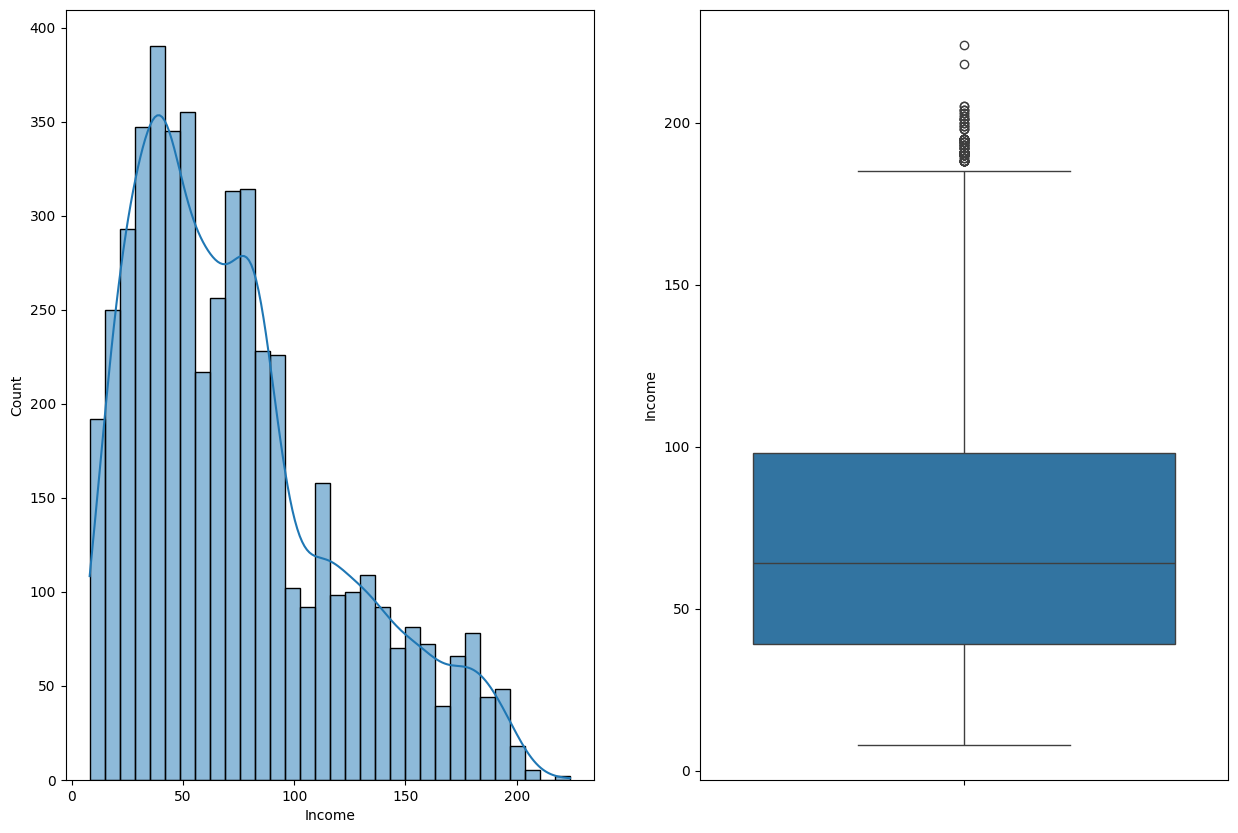

In [76]:
#Histogram and Boxplot for Income
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
sns.histplot(data['Income'], kde=True)
plt.subplot(1,2,2)
sns.boxplot(data['Income'])
plt.show();

#### **Observatio**

**Histogram Observations**
- The distribution is right-skewed, the majority of customers earn between 20K to 60K dollars, with the peak around 40K dollars, and a long tail extending up to 224K dollars, indicating a few high-income earners.

**Boxplot Observations**
- The box ranges from around 45 to 100, with the median close to 65K, showing a right-skewed distribution where most customers fall into the lower to middle income range.

- There are clear outliers above roughly 190K. These likely represent genuinely high-income customers rather than errors, as such values are realistic in a banking dataset.

In [77]:
#calculate basic statistics (mean, median, minimum, and maximum) for Income
print('Mean:',data['Income'].mean())
print('Median:',data['Income'].median())
print('Min:',data['Income'].min())
print('Max:',data['Income'].max())

Mean: 73.7742
Median: 64.0
Min: 8
Max: 224


### Zip Code

In [78]:
#unique values
data['ZIPCode'].unique().shape

(467,)

#### **Observation**
- There are 467 unique ZIP codes among 5000 customers, which means the feature has high cardinality. Most ZIP codes appear only a few times, so it doesn’t add much value for analysis or modeling and may not be very useful to include.

In [79]:
#Top 5 Areas by Customer Count
data['ZIPCode'].value_counts().head()

,count
ZIPCode,
94720,169
94305,127
95616,116
90095,71
93106,57


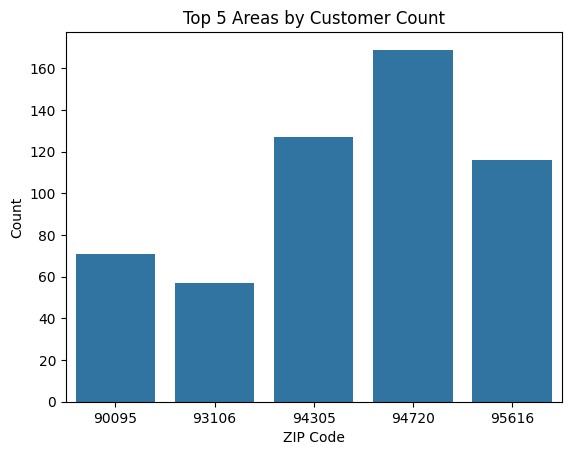

In [80]:
#barplot for Zip Code
sns.barplot(x=data['ZIPCode'].value_counts().head().index,
            y=data['ZIPCode'].value_counts().head().values)
plt.title('Top 5 Areas by Customer Count')
plt.xlabel('ZIP Code')
plt.ylabel('Count')
plt.show()

#### **Observation**
- ZIP code 94720 has the highest number of customers, followed by 94305 and 95616.
- There is a sharp drop after the top 3 — 90095 and 93106 have significantly fewer customers, indicating most ZIP codes are very thinly populated in this dataset.

### Family

In [81]:
#Count of each Family Size
df1 = data['Family'].value_counts()

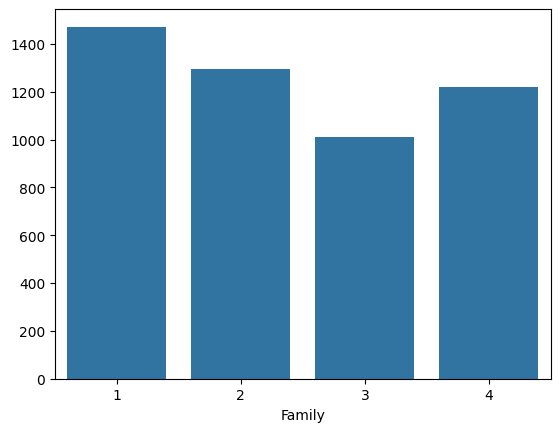

In [82]:
#barplot for Family size
sns.barplot(x = df1.index,y = df1.values)
plt.show();

#### **Observation**
- Single-member families are the most common , followed by family sizes of 2 and 4. Family size 3 has the lowest count, but overall the distribution remains fairly balanced.
- The distribution is roughly even across all family sizes with no extreme dominance, suggesting the bank serves a diverse household demographic.

### CCAvg

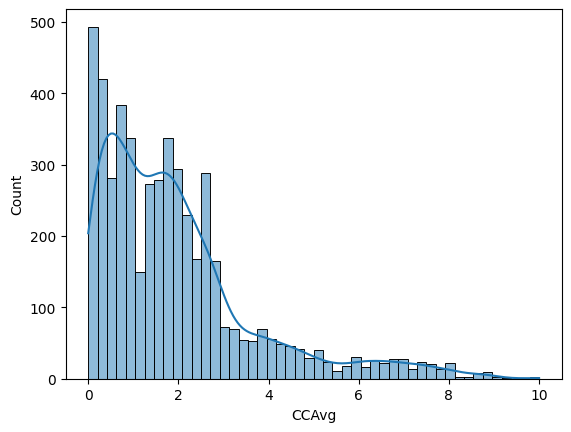

In [83]:
#Histogram for CCAvg
sns.histplot(data['CCAvg'], kde=True)
plt.show();

#### **Observation**
- The distribution is strongly right-skewed — most customers spend between 0 to 2K dollars per month on credit cards, with the highest concentration near 0 and a long tail extending up to 10K dollars.

### Education

In [84]:
df2 = data['Education'].value_counts()
df2

,count
Education,
1,2096
3,1501
2,1403


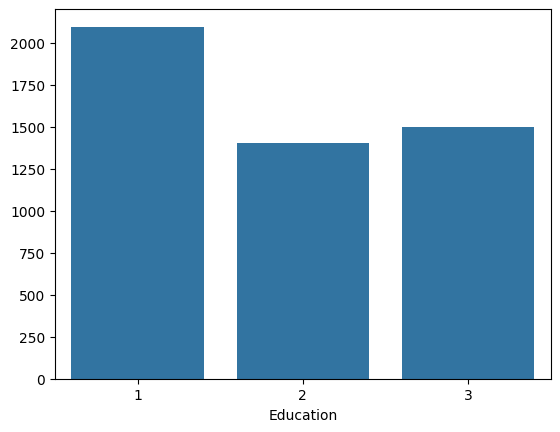

In [85]:
#barplot for Education
sns.barplot(x = df2.index,y = df2.values)
plt.show();

### Mortgage

In [86]:
(data['Mortgage'] == 0).value_counts()

,count
Mortgage,
True,3462
False,1538


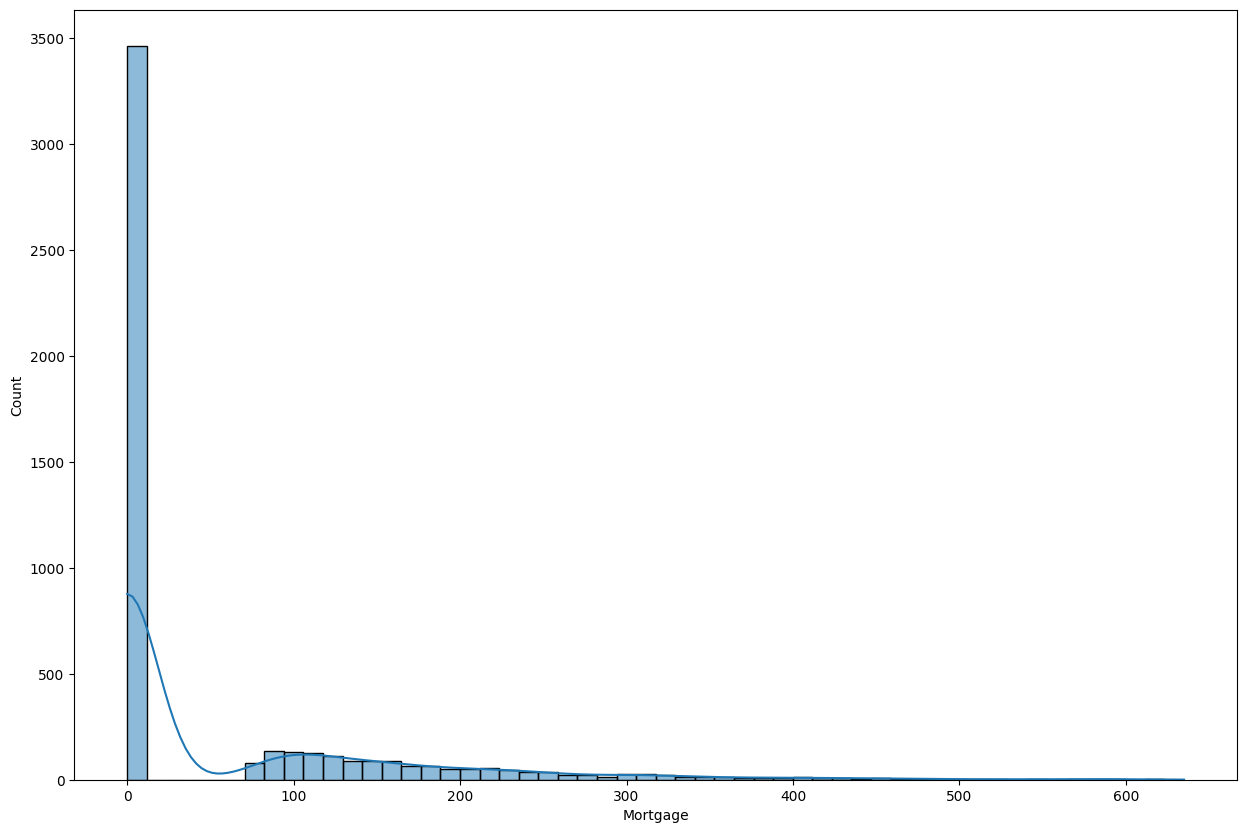

In [87]:
plt.figure(figsize=(15,10))
sns.histplot(data['Mortgage'], kde=True)
plt.show();

#### **Observation**
- The distribution is heavily right-skewed, with about 69.2% of customers having no mortgage, creating a large spike at 0. The remaining customers have mortgage values ranging from around 1K to 635K dollars.

### Personal Loan

In [88]:
df3 = data['Personal_Loan'].value_counts()
df3

,count
Personal_Loan,
0,4520
1,480


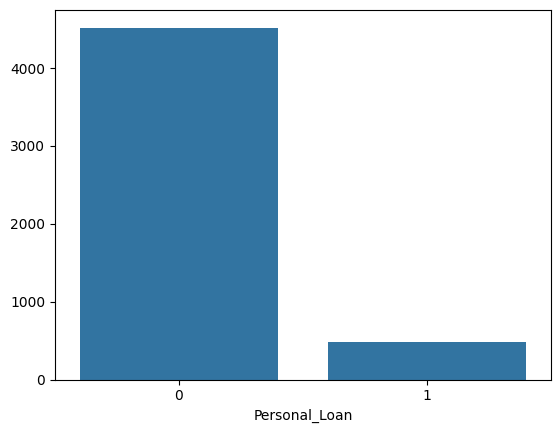

In [89]:
sns.barplot(x = df3.index,y = df3.values)
plt.show();

### Security Account

In [90]:
df4 = data['Securities_Account'].value_counts()
df4

,count
Securities_Account,
0,4478
1,522


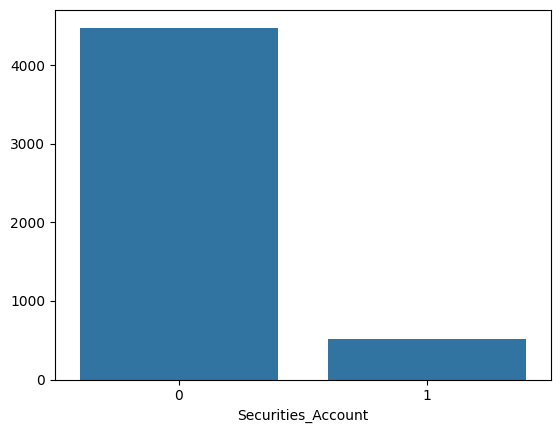

In [91]:
sns.barplot(x = df4.index,y = df4.values)
plt.show();

### CD Account

In [92]:
df5 = data['CD_Account'].value_counts()
df5

,count
CD_Account,
0,4698
1,302


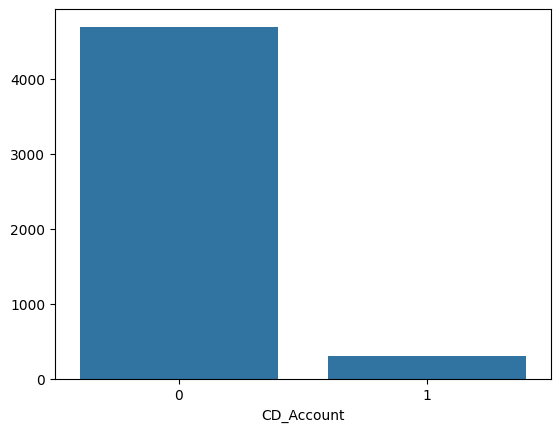

In [93]:
sns.barplot(x = df5.index,y = df5.values)
plt.show();

### Online

In [94]:
df6= data['Online'].value_counts()
df6

,count
Online,
1,2984
0,2016


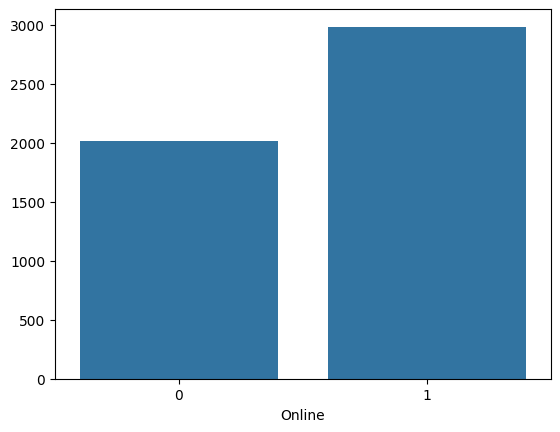

In [95]:
sns.barplot(x = df6.index,y = df6.values)
plt.show();

### Credit Card

In [96]:
df7 = data['CreditCard'].value_counts()
df7

,count
CreditCard,
0,3530
1,1470


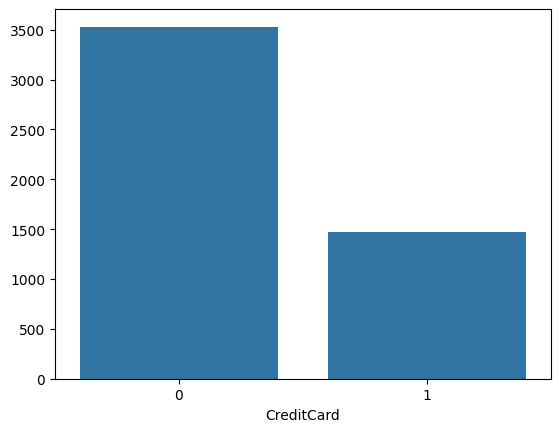

In [97]:
sns.barplot(x = df7.index,y = df7.values)
plt.show();

###

## **Bivariate Analysis**

### **Income vs Education**

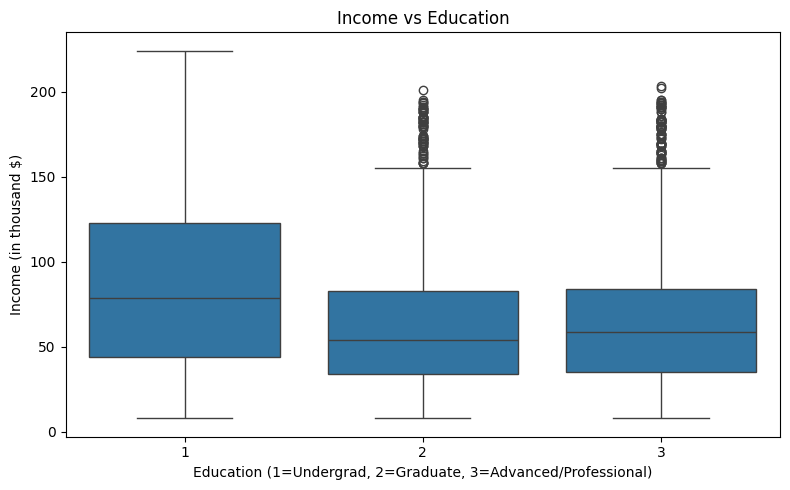

In [98]:
# boxplot Education vs Income
plt.figure(figsize=(8,5))
sns.boxplot(x='Education', y='Income', data=data)
plt.title('Income vs Education')
plt.xlabel('Education (1=Undergrad, 2=Graduate, 3=Advanced/Professional)')
plt.ylabel('Income (in thousand $)')
plt.tight_layout()
plt.show()

#### **Observation**
- Undergraduates have the highest median income compared to Graduate and Advanced/Professional, which is counterintuitive.
- Undergraduates also have the widest income spread, indicating high variability in their earnings.

### **Income vs Personal Loan**

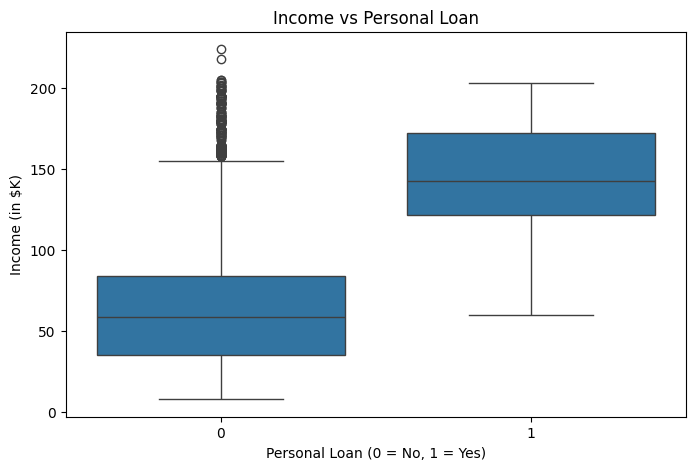

In [99]:
# Boxplot: Income vs Personal Loan
plt.figure(figsize=(8,5))
sns.boxplot(x='Personal_Loan', y='Income', data=data)
plt.xlabel('Personal Loan (0 = No, 1 = Yes)')
plt.ylabel('Income (in $K)')
plt.title('Income vs Personal Loan')
plt.show();

#### **Observation:**
- Customers who accepted the personal loan (1) have noticeably **higher incomes** than those who did not (0).
- This suggests income is a strong predictor of loan acceptance.

### **Income vs Family Size**

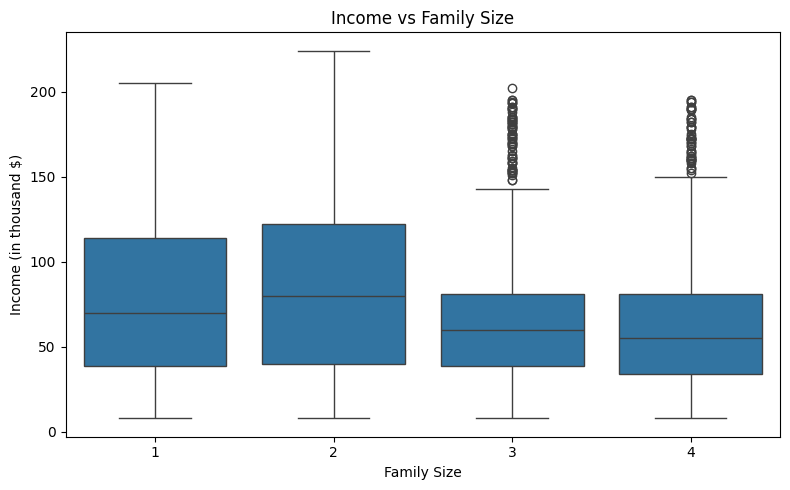

In [100]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Family', y='Income', data=data)
plt.title('Income vs Family Size')
plt.xlabel('Family Size')
plt.ylabel('Income (in thousand $)')
plt.tight_layout()
plt.show()

#### **Observation**
- Family sizes 1 and 2 have higher median incomes (70K and 80K) compared to sizes 3 and 4 (60K and 55K), suggesting smaller families tend to earn more.
- Family sizes 3 and 4 have a tighter income range.
- Family sizes 3 and 4 have high-income outliers, but the overall income distribution decreases as family size increases.

### **CCAvg vs Education**



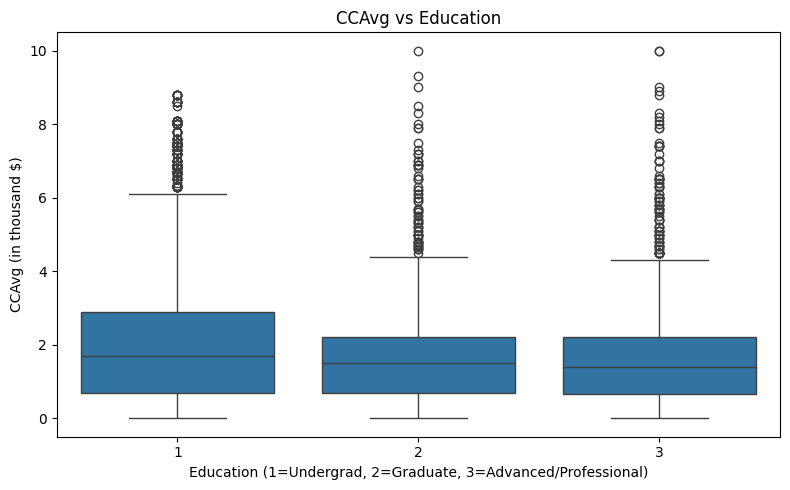

In [101]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Education', y='CCAvg', data=data)
plt.title('CCAvg vs Education')
plt.xlabel('Education (1=Undergrad, 2=Graduate, 3=Advanced/Professional)')
plt.ylabel('CCAvg (in thousand $)')
plt.tight_layout()
plt.show()

#### **Observation**
- Median CCAvg is very similar across all education levels, suggesting education level does not strongly influence credit card spending.
- Undergraduates have a slightly higher median and wider spread compared to Graduate and Advanced/Professional customers.
- Overall, CCAvg distributions are quite comparable across education levels, indicating little to no relationship between education and credit card spending behavior.

### **CCAvg vs Personal Loan**

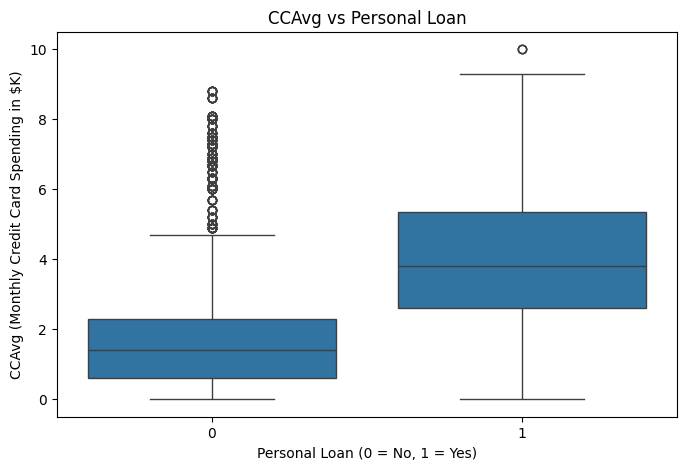

In [102]:
# Boxplot: Credit Card Average Spending vs Personal Loan
plt.figure(figsize=(8,5))
sns.boxplot(x='Personal_Loan', y='CCAvg', data=data)
plt.xlabel('Personal Loan (0 = No, 1 = Yes)')
plt.ylabel('CCAvg (Monthly Credit Card Spending in $K)')
plt.title('CCAvg vs Personal Loan')
plt.show();

#### **Observation:**
- Customers who accepted the loan also tend to spend more on credit cards on average.
- Higher CCAvg is positively associated with loan acceptance.

## **CCAvg vs Family Size**

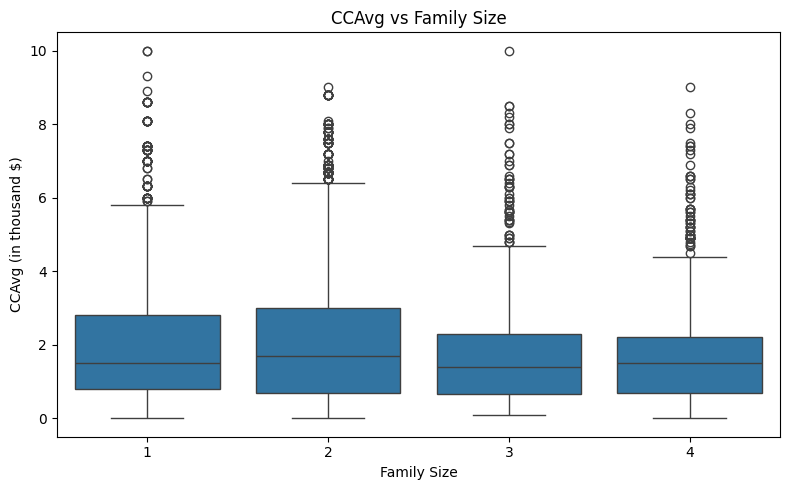

In [103]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Family', y='CCAvg', data=data)
plt.title('CCAvg vs Family Size')
plt.xlabel('Family Size')
plt.ylabel('CCAvg (in thousand $)')
plt.tight_layout()
plt.show()

#### **Observations**

- Median CCAvg is very similar across all family sizes, suggesting family size does not strongly influence credit card spending.
- Family sizes 1 and 2 have a slightly wider spread, indicating some tendency for smaller families to spend more on credit cards.
- All family sizes contain high-spending outliers, and the overall distributions are quite comparable — CCAvg and family size appear to have
**little to no relationship**.

### **Education vs Personal Loan**

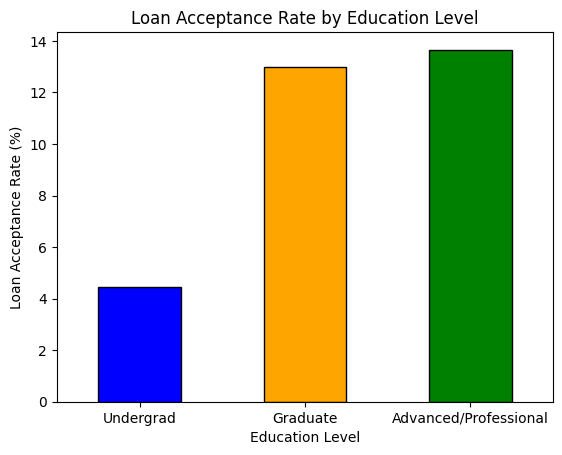

Undergrad                 4.437023
Graduate                 12.972202
Advanced/Professional    13.657562
Name: Personal_Loan, dtype: float64


In [104]:
# Bar chart: Education level vs Loan Acceptance Rate
education_loan = data.groupby('Education')['Personal_Loan'].mean() * 100
education_loan.index = ['Undergrad', 'Graduate', 'Advanced/Professional']
education_loan.plot(kind='bar', color=['blue','orange','green'], edgecolor='black')
plt.ylabel('Loan Acceptance Rate (%)')
plt.xlabel('Education Level')
plt.title('Loan Acceptance Rate by Education Level')
plt.xticks(rotation=0)
plt.show();
print(education_loan)

#### **Observation**
- Graduate and Advanced/Professional customers have significantly higher loan acceptance rates compared to Undergraduates.
- Education level plays an important role in loan decisions.

### **CD Account vs Personal Loan**

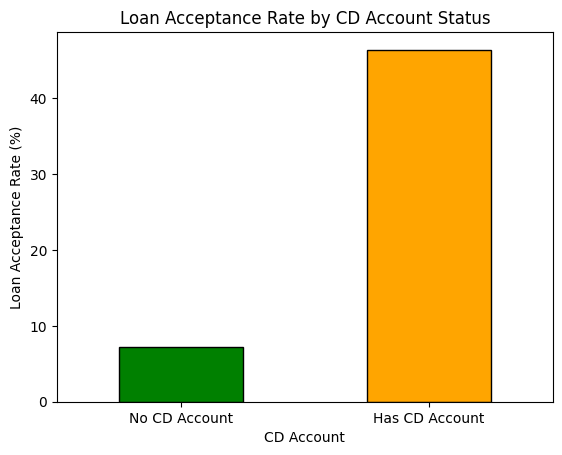

No CD Account      7.237122
Has CD Account    46.357616
Name: Personal_Loan, dtype: float64


In [105]:
# Cross-tabulation: CD Account vs Personal Loan
cd_loan = data.groupby('CD_Account')['Personal_Loan'].mean() * 100
cd_loan.index = ['No CD Account', 'Has CD Account']
cd_loan.plot(kind='bar', color=['green', 'orange'], edgecolor='black')
plt.ylabel('Loan Acceptance Rate (%)')
plt.xlabel('CD Account')
plt.title('Loan Acceptance Rate by CD Account Status')
plt.xticks(rotation=0)
plt.show();
print(cd_loan)

#### **Observation**
- Customers with a CD account have a much higher loan acceptance rate compared to those without one.
- CD_Account is a very strong indicator of loan acceptance.

### **Family Size vs Personal Loan**

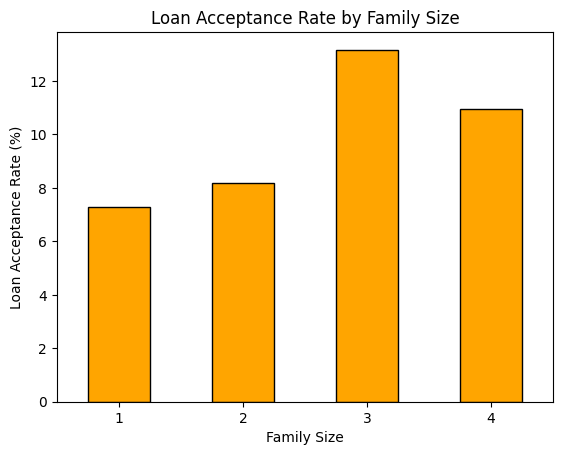

Family
1     7.269022
2     8.179012
3    13.168317
4    10.965630
Name: Personal_Loan, dtype: float64


In [106]:
# Family size vs Loan Acceptance Rate
family_loan = data.groupby('Family')['Personal_Loan'].mean() * 100
family_loan.plot(kind='bar', color='orange', edgecolor='black')
plt.ylabel('Loan Acceptance Rate (%)')
plt.xlabel('Family Size')
plt.title('Loan Acceptance Rate by Family Size')
plt.xticks(rotation=0)
plt.show();
print(family_loan)

#### **Observation**
- Larger families tend to have higher loan acceptance rates.
- Family size shows a moderate positive relationship with loan acceptance.

### **Correlation Heatmap**

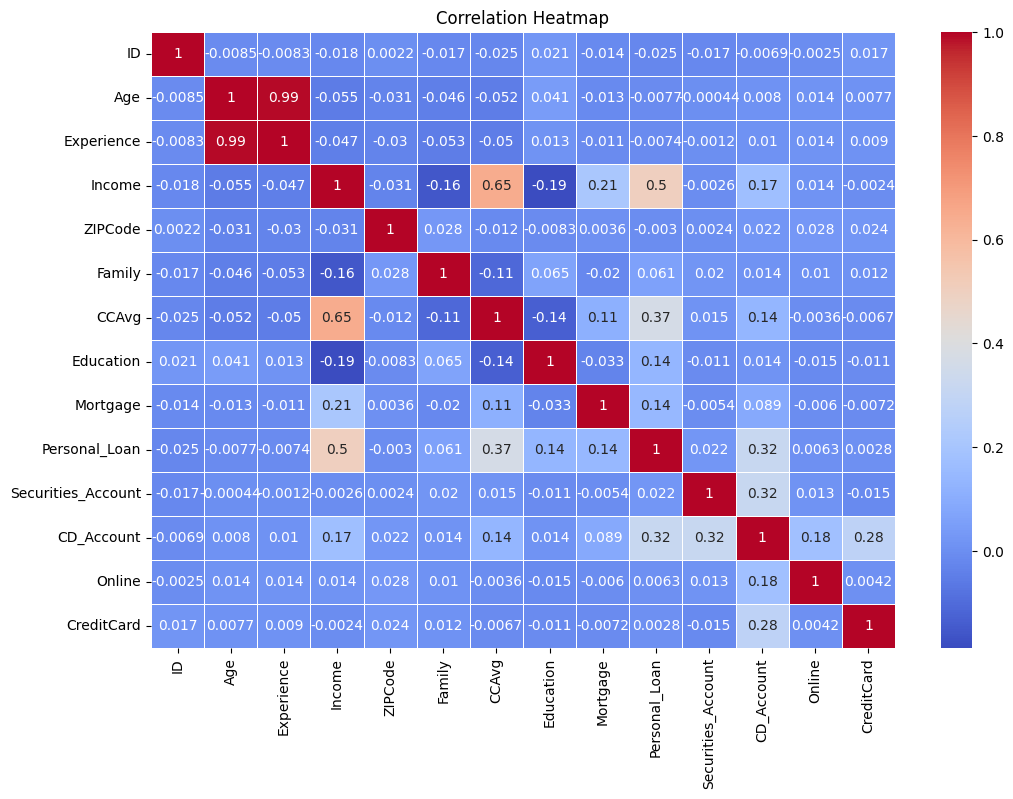

In [107]:
plt.figure(figsize=(12,8))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show();

**Key Observations from Correlation Heatmap:**
- **Income** and **CCAvg** are positively correlated with Personal_Loan.
- **CD_Account** has a strong positive correlation with Personal_Loan.
- **Age** and **Experience** are highly correlated with each other, but less so with Personal_Loan.
- **ZIPCode** shows very low correlation with everything — confirms it's not useful.

# **Data Pre-processing**

## **Handling Negative Experience Values**

In [108]:
# Negative Experience Values
df_neg=data[data['Experience']<0]

In [109]:
# Positive Experience Values, Experince in between 1 and3
df_pov = data[(data['Experience'] > 0) & (data['Experience'] < 4)]

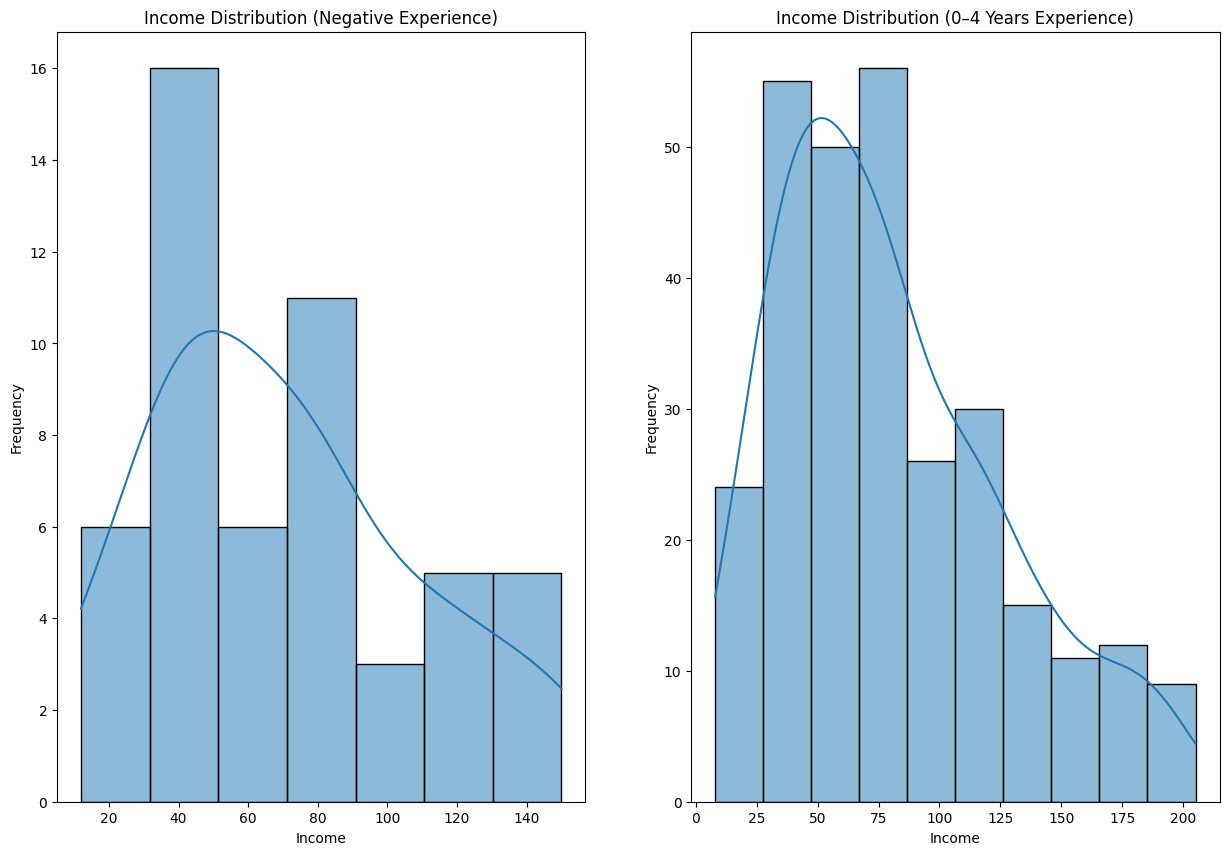

In [110]:
# Ploting the distribution between Negative and Positive Experience
plt.figure(figsize=(15,10))
# First plot
plt.subplot(1,2,1)
sns.histplot(df_neg['Income'], kde=True)
plt.title('Income Distribution (Negative Experience)')
plt.xlabel('Income')
plt.ylabel('Frequency')
# Second plot
plt.subplot(1,2,2)
sns.histplot(df_pov['Income'], kde=True)
plt.title('Income Distribution (0–4 Years Experience)')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

#### **Observation**
- The negative values are clearly data entry errors, experience cannot be negative in reality.
- Since the income profiles of Experience = -2 and Experience = +2 are similar, taking the absolute value preserves meaningful information rather than discarding it by clipping to 0.
- Clipping to 0 would incorrectly label a customer with 2 years of experience as having no experience, which would distort the model.


### **Data Transformation**
#### **Experience Column**

In [111]:
# Changeing Negative experince to positive experince by using abs()
data['Experience'] = abs(data['Experience'])

### **Dropping Irrelevant Features**

In [115]:
# Drop ID (customer identifier, not a feature) and ZIPCode (high cardinality, low signal)
data1 = data.drop(columns=[ 'ID'])
print('Remaining columns:', list(data1.columns))

Remaining columns: ['Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']


### **Checking for Outliers**

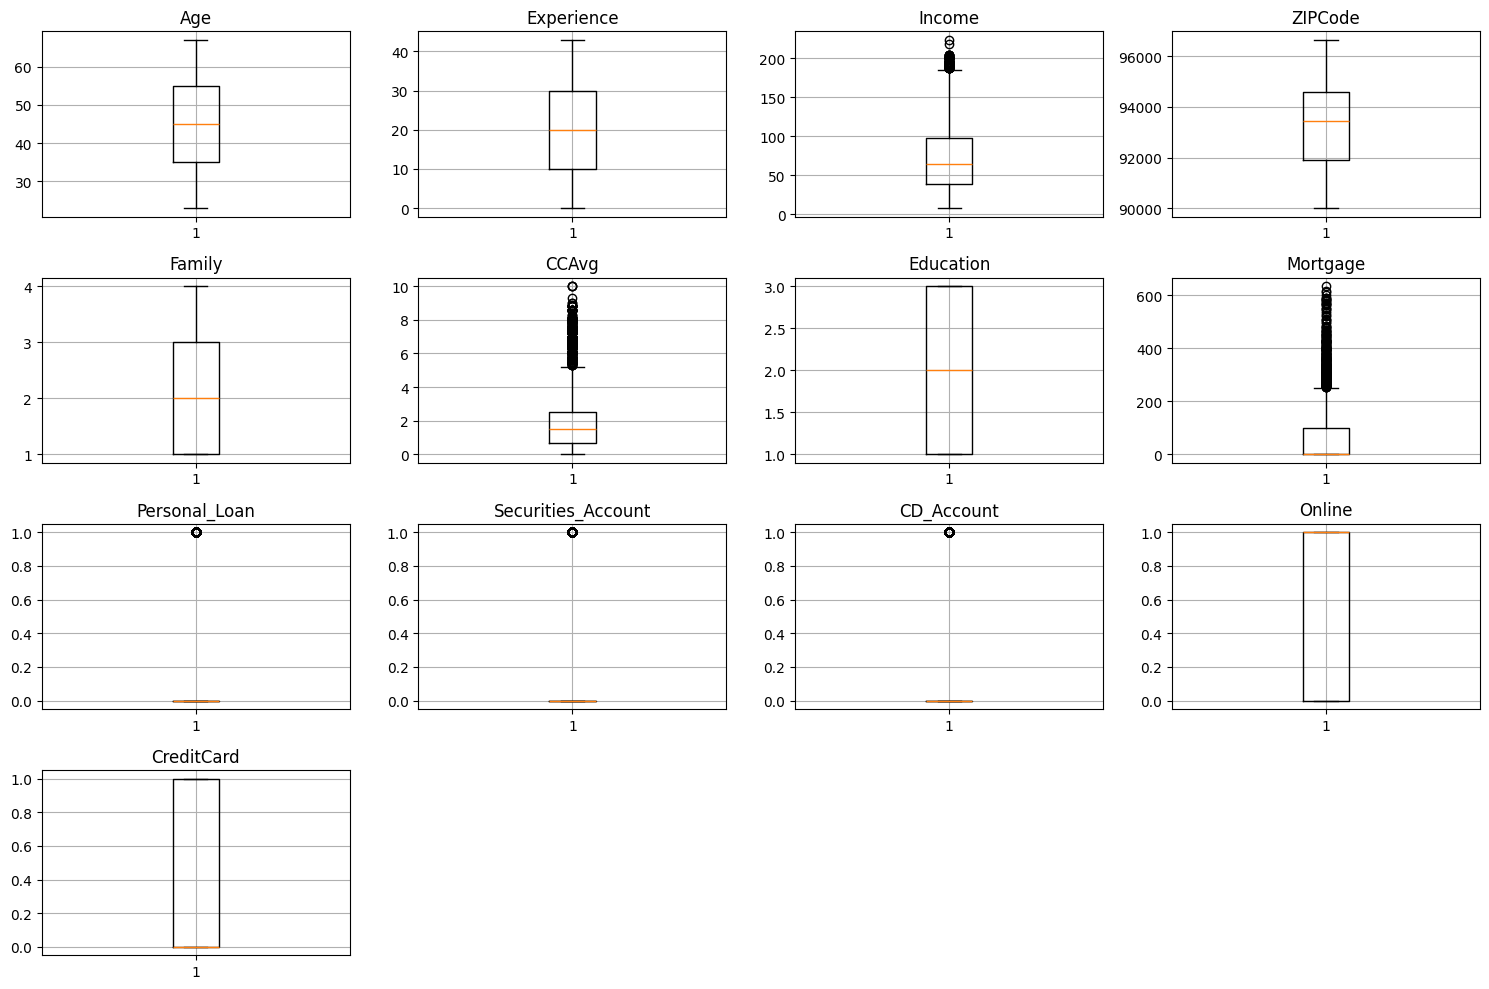

In [116]:
# Outliers Detection using boxplot
plt.figure(figsize=(15, 10))

for i, col in enumerate(data1.columns, 1):
    plt.subplot(4, 4, i)
    plt.boxplot(data1[col])

    plt.title(f"{col}")
    plt.grid(True)

plt.tight_layout()
plt.show()

#### **Observation**
- **Income** and **CCAvg** have high outliers, but they represent genuine high-income, high-spending customers.
- We will **retain** these outliers since Decision Trees are robust to outliers.

## **Preparing Data for Modelling**

In [117]:
# Define features (X) and target (y)
X = data1.drop(columns=['Personal_Loan'])  # All features except target
y = data1['Personal_Loan']                 # Target: 0 = No Loan, 1 = Loan

# Split into train and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print('Training set size:', X_train.shape)
print('Testing set size: ', X_test.shape)
print('\nClass distribution in training set:')
print(y_train.value_counts())
print('\nClass distribution in test set:')
print(y_test.value_counts())

Training set size: (3500, 12)
Testing set size:  (1500, 12)

Class distribution in training set:
Personal_Loan
0    3177
1     323
Name: count, dtype: int64

Class distribution in test set:
Personal_Loan
0    1343
1     157
Name: count, dtype: int64


- We split the data **70/30** (train/test).
- The dataset is imbalanced — about **9.6% of customers accepted the loan**.
  We will keep this in mind when evaluating the model.

# **Model Building — Decision Tree**

## **Defining Model Evaluation Criterion**

**Evaluation Metrics we will use:**
- **Accuracy** — Overall correct predictions.
- **Precision** — Of all predicted loan acceptors, how many actually accepted?
- **Recall** — Of all actual loan acceptors, how many did we correctly identify?
- **F1 Score** — Harmonic mean of Precision and Recall (important for imbalanced data).
- **Confusion Matrix** — Full breakdown of TP, TN, FP, FN.

Since the dataset is **imbalanced (~9.6% positive class)**, we care especially about **Recall and F1 Score** for class 1 (loan acceptors).

## **Building the Base Decision Tree (No Pruning)**

In [118]:
# Build the base decision tree with no restrictions
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

# Predictions
y_pred_base = dt_base.predict(X_test)

# Evaluation
print('=== Base Decision Tree (No Pruning) ===')
print(f'Train Accuracy: {dt_base.score(X_train, y_train):.4f}')
print(f'Test  Accuracy: {accuracy_score(y_test, y_pred_base):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_base))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_base))

=== Base Decision Tree (No Pruning) ===
Train Accuracy: 1.0000
Test  Accuracy: 0.9827

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.92      0.91      0.92       157

    accuracy                           0.98      1500
   macro avg       0.96      0.95      0.95      1500
weighted avg       0.98      0.98      0.98      1500


Confusion Matrix:
[[1331   12]
 [  14  143]]


**Observation:**
- The base tree achieves **very high train accuracy** but may be overfitting (train accuracy >> test accuracy).
- A fully grown tree memorizes the training data and may not generalize well.
- We need to **prune** the tree to improve generalization.

## **Visualizing the Base Decision Tree (Top 3 Levels)**

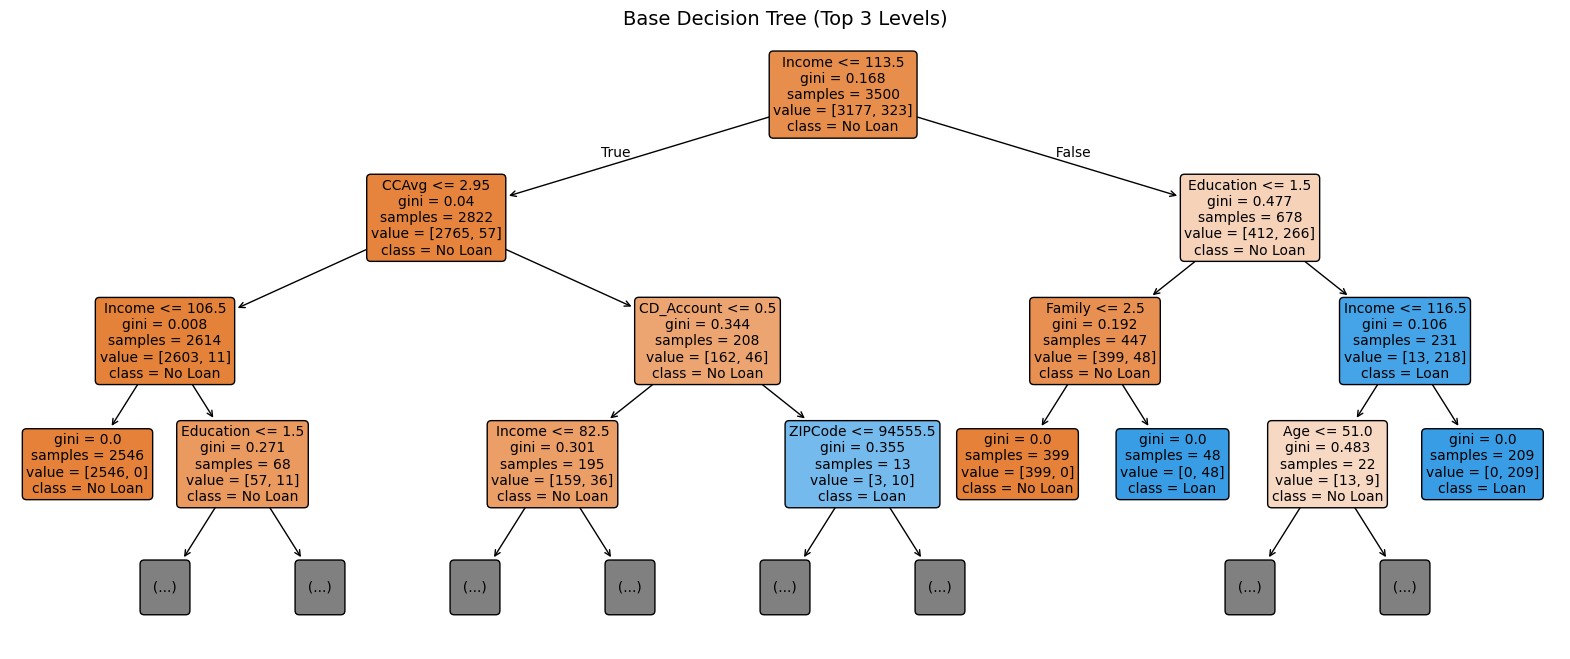

In [120]:
# Visualize the top 3 levels of the tree
plt.figure(figsize=(20, 8))
plot_tree(
    dt_base,
    feature_names=X_train.columns,
    class_names=['No Loan', 'Loan'],
    filled=True,
    max_depth=3,  # Show only top 3 levels for readability
    rounded=True,
    fontsize=10
)
plt.title('Base Decision Tree (Top 3 Levels)', fontsize=14)
plt.show();

# **Model Performance Evaluation and Improvement**

## **Pre-Pruning (Using max_depth)**

**Pre-Pruning** stops the tree from growing too deep during training itself.
We set a **maximum depth** to prevent overfitting.